In [1]:
import os
import numpy as np
from vit_keras import vit
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers

os.environ["CUDA_VISIBLE_DEVICES"]= "0"

2025-01-29 14:45:34.166250: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-29 14:45:34.262086: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-29 14:45:34.712203: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/kannika/miniconda3/envs/AI/lib/
2025-01-29 14:45:34.712259: W tensorflow/compile

## Load ViTL-32 : Train on USAI 15AB Balanced Dataset

In [2]:
model_dir = '/media/tohn/HDD2/Model_unlearn/Models_USAI/ViTModel/ViTorigin_USAI/R1_balanced/exp1/models/modelVITL32_USAI15ab-R1_balanced.h5'
model = load_model(model_dir)
height = width = model.input_shape[1]
print(height, width)

2025-01-29 14:46:01.947690: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-29 14:46:02.359283: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9619 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:17:00.0, compute capability: 7.5


384 384


In [3]:
model.summary()

Model: "ViT_USAI"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 384, 384, 3)]     0         
                                                                 
 embedding (Conv2D)          (None, 12, 12, 1024)      3146752   
                                                                 
 reshape (Reshape)           (None, 144, 1024)         0         
                                                                 
 class_token (ClassToken)    (None, 145, 1024)         1024      
                                                                 
 Transformer/posembed_input   (None, 145, 1024)        148480    
 (AddPositionEmbs)                                               
                                                                 
 Transformer/encoderblock_0   ((None, 145, 1024),      12596224  
 (TransformerBlock)           (None, 16, None, None))     

In [4]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [5]:
len(set(dataframe['Sub_class_New']))

15

In [6]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [7]:
batch_size = 64
epochs = 10

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [8]:
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    print("Predict Image: ", i+1)
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])

Predict Image:  1


2025-01-29 14:47:09.959501: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8100
2025-01-29 14:47:10.318756: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 5s 5s/step
Predict Image:  2
1/1 [==============================] - 0s 67ms/step
Predict Image:  3
1/1 [==============================] - 0s 67ms/step
Predict Image:  4
1/1 [==============================] - 0s 68ms/step
Predict Image:  5
1/1 [==============================] - 0s 69ms/step
Predict Image:  6
1/1 [==============================] - 0s 69ms/step
Predict Image:  7
1/1 [==============================] - 0s 67ms/step
Predict Image:  8
1/1 [==============================] - 0s 85ms/step
Predict Image:  9
1/1 [==============================] - 0s 67ms/step
Predict Image:  10
1/1 [==============================] - 0s 66ms/step
Predict Image:  11
1/1 [==============================] - 0s 68ms/step
Predict Image:  12
1/1 [==============================] - 0s 65ms/step
Predict Image:  13
1/1 [==============================] - 0s 66ms/step
Predict Image:  14
1/1 [==============================] - 0s 65ms/step
Predict Image:  15
1/1 [===========

1/1 [==============================] - 0s 68ms/step
Predict Image:  117
1/1 [==============================] - 0s 68ms/step
Predict Image:  118
1/1 [==============================] - 0s 68ms/step
Predict Image:  119
1/1 [==============================] - 0s 86ms/step
Predict Image:  120
1/1 [==============================] - 0s 65ms/step
Predict Image:  121
1/1 [==============================] - 0s 64ms/step
Predict Image:  122
1/1 [==============================] - 0s 66ms/step
Predict Image:  123
1/1 [==============================] - 0s 78ms/step
Predict Image:  124
1/1 [==============================] - 0s 67ms/step
Predict Image:  125
1/1 [==============================] - 0s 68ms/step
Predict Image:  126
1/1 [==============================] - 0s 68ms/step
Predict Image:  127
1/1 [==============================] - 0s 66ms/step
Predict Image:  128
1/1 [==============================] - 0s 67ms/step
Predict Image:  129
1/1 [==============================] - 0s 66ms/step
Predict Imag

1/1 [==============================] - 0s 64ms/step
Predict Image:  231
1/1 [==============================] - 0s 69ms/step
Predict Image:  232
1/1 [==============================] - 0s 68ms/step
Predict Image:  233
1/1 [==============================] - 0s 67ms/step
Predict Image:  234
1/1 [==============================] - 0s 67ms/step
Predict Image:  235
1/1 [==============================] - 0s 69ms/step
Predict Image:  236
1/1 [==============================] - 0s 65ms/step
Predict Image:  237
1/1 [==============================] - 0s 67ms/step
Predict Image:  238
1/1 [==============================] - 0s 68ms/step
Predict Image:  239
1/1 [==============================] - 0s 65ms/step
Predict Image:  240
1/1 [==============================] - 0s 64ms/step
Predict Image:  241
1/1 [==============================] - 0s 67ms/step
Predict Image:  242
1/1 [==============================] - 0s 64ms/step
Predict Image:  243
1/1 [==============================] - 0s 69ms/step
Predict Imag

...

1/1 [==============================] - 0s 66ms/step
Predict Image:  801
1/1 [==============================] - 0s 67ms/step
Predict Image:  802
1/1 [==============================] - 0s 68ms/step
Predict Image:  803
1/1 [==============================] - 0s 66ms/step
Predict Image:  804
1/1 [==============================] - 0s 65ms/step
Predict Image:  805
1/1 [==============================] - 0s 67ms/step
Predict Image:  806
1/1 [==============================] - 0s 66ms/step
Predict Image:  807
1/1 [==============================] - 0s 64ms/step
Predict Image:  808
1/1 [==============================] - 0s 67ms/step
Predict Image:  809
1/1 [==============================] - 0s 65ms/step
Predict Image:  810
1/1 [==============================] - 0s 66ms/step
Predict Image:  811
1/1 [==============================] - 0s 66ms/step
Predict Image:  812
1/1 [==============================] - 0s 67ms/step
Predict Image:  813
1/1 [==============================] - 0s 66ms/step
Predict Imag

1/1 [==============================] - 0s 80ms/step
Predict Image:  915
1/1 [==============================] - 0s 65ms/step
Predict Image:  916
1/1 [==============================] - 0s 76ms/step
Predict Image:  917
1/1 [==============================] - 0s 69ms/step
Predict Image:  918
1/1 [==============================] - 0s 71ms/step
Predict Image:  919
1/1 [==============================] - 0s 81ms/step
Predict Image:  920
1/1 [==============================] - 0s 65ms/step
Predict Image:  921
1/1 [==============================] - 0s 67ms/step
Predict Image:  922
1/1 [==============================] - 0s 67ms/step
Predict Image:  923
1/1 [==============================] - 0s 66ms/step
Predict Image:  924
1/1 [==============================] - 0s 64ms/step
Predict Image:  925
1/1 [==============================] - 0s 65ms/step
Predict Image:  926
1/1 [==============================] - 0s 68ms/step
Predict Image:  927
1/1 [==============================] - 0s 68ms/step
Predict Imag

1/1 [==============================] - 0s 67ms/step
Predict Image:  1028
1/1 [==============================] - 0s 70ms/step
Predict Image:  1029
1/1 [==============================] - 0s 67ms/step
Predict Image:  1030
1/1 [==============================] - 0s 68ms/step
Predict Image:  1031
1/1 [==============================] - 0s 66ms/step
Predict Image:  1032
1/1 [==============================] - 0s 67ms/step
Predict Image:  1033
1/1 [==============================] - 0s 67ms/step
Predict Image:  1034
1/1 [==============================] - 0s 66ms/step
Predict Image:  1035
1/1 [==============================] - 0s 71ms/step
Predict Image:  1036
1/1 [==============================] - 0s 68ms/step
Predict Image:  1037
1/1 [==============================] - 0s 65ms/step
Predict Image:  1038
1/1 [==============================] - 0s 67ms/step
Predict Image:  1039
1/1 [==============================] - 0s 64ms/step
Predict Image:  1040
1/1 [==============================] - 0s 65ms/step

1/1 [==============================] - 0s 72ms/step
Predict Image:  1140
1/1 [==============================] - 0s 76ms/step
Predict Image:  1141
1/1 [==============================] - 0s 70ms/step
Predict Image:  1142
1/1 [==============================] - 0s 66ms/step
Predict Image:  1143
1/1 [==============================] - 0s 73ms/step
Predict Image:  1144
1/1 [==============================] - 0s 68ms/step
Predict Image:  1145
1/1 [==============================] - 0s 71ms/step
Predict Image:  1146
1/1 [==============================] - 0s 72ms/step
Predict Image:  1147
1/1 [==============================] - 0s 69ms/step
Predict Image:  1148
1/1 [==============================] - 0s 72ms/step
Predict Image:  1149
1/1 [==============================] - 0s 74ms/step
Predict Image:  1150
1/1 [==============================] - 0s 71ms/step
Predict Image:  1151
1/1 [==============================] - 0s 71ms/step
Predict Image:  1152
1/1 [==============================] - 0s 72ms/step

1/1 [==============================] - 0s 64ms/step
Predict Image:  1252
1/1 [==============================] - 0s 65ms/step
Predict Image:  1253
1/1 [==============================] - 0s 65ms/step
Predict Image:  1254
1/1 [==============================] - 0s 67ms/step
Predict Image:  1255
1/1 [==============================] - 0s 82ms/step
Predict Image:  1256
1/1 [==============================] - 0s 66ms/step
Predict Image:  1257
1/1 [==============================] - 0s 66ms/step
Predict Image:  1258
1/1 [==============================] - 0s 66ms/step
Predict Image:  1259
1/1 [==============================] - 0s 77ms/step
Predict Image:  1260
1/1 [==============================] - 0s 69ms/step
Predict Image:  1261
1/1 [==============================] - 0s 66ms/step
Predict Image:  1262
1/1 [==============================] - 0s 66ms/step
Predict Image:  1263
1/1 [==============================] - 0s 65ms/step
Predict Image:  1264
1/1 [==============================] - 0s 67ms/step

In [9]:
dataframe['category'] = pred_list
dataframe['Prob'] = prob_list
print(dataframe.shape)
dataframe.head()

(1312, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,AB02,1.0
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.0
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,1.0
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB02,1.0
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB01,1.0


In [10]:
dataframe.to_csv("/home/kannika/code/Evaluation_modelVITL32_USAI15ab-R1_balanced.csv")

# Evaluation

In [11]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB02', 'AB01', 'AB11', 'AB10', 'AB12', 'Normal', 'AB06', 'AB04', 'AB083', 'AB09', 'AB081', 'AB03', 'AB082', 'AB07', 'AB05'}
Actual :  15
{'AB01', 'AB02', 'AB11', 'AB10', 'AB12', 'Normal', 'AB06', 'AB04', 'AB083', 'AB09', 'AB081', 'AB03', 'AB082', 'AB07', 'AB05'}


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 86.58536585365853%
              precision    recall  f1-score   support

        AB01       0.69      0.73      0.71        74
        AB02       0.61      0.59      0.60        59
        AB03       0.45      0.53      0.49        19
        AB04       0.86      0.50      0.63        38
        AB05       0.75      0.52      0.61        29
        AB06       0.61      0.52      0.56        21
        AB07       0.77      0.48      0.59        21
       AB081       0.85      0.53      0.65        32
       AB082       0.94      0.61      0.74        28
       AB083       0.62      0.73      0.67        11
        AB09       0.96      0.85      0.90        26
        AB10       1.00      0.40      0.57        10
        AB11       0.96      0.93      0.94        55
        AB12       0.88      0.88      0.88        32
      Normal       0.91      0.97      0.94       857

    accuracy                           0.87      1312
   macro avg       0.79      0.65      

Text(0.5, 21.249999999999993, 'Predicted label')

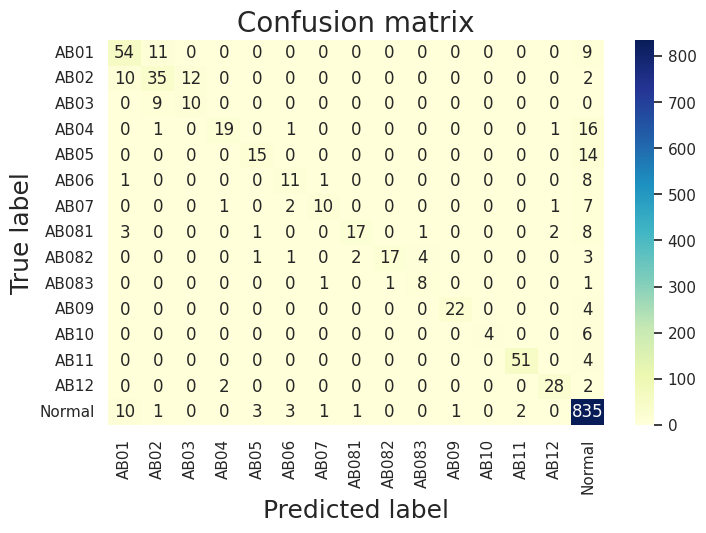

In [13]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [14]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 91.92073170731707%
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       857
           1       0.94      0.82      0.88       455

    accuracy                           0.92      1312
   macro avg       0.93      0.89      0.91      1312
weighted avg       0.92      0.92      0.92      1312



835 22 84 371


Text(66.25, 0.5, 'True label')

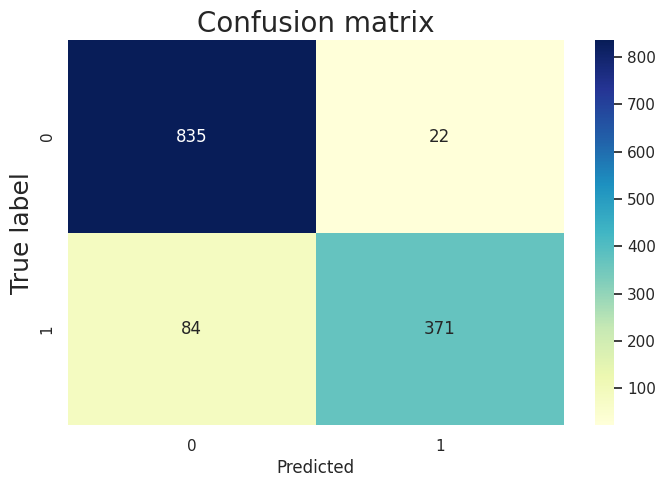

In [15]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [16]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB01
classifier accuracy = 0.7297297297297297% 

###### AB02
classifier accuracy = 0.5932203389830508% 

###### AB11
classifier accuracy = 0.9272727272727272% 

###### AB10
classifier accuracy = 0.4% 

###### AB12
classifier accuracy = 0.875% 

###### Normal
classifier accuracy = 0.9743290548424738% 

###### AB06
classifier accuracy = 0.5238095238095238% 

###### AB04
classifier accuracy = 0.5% 

###### AB083
classifier accuracy = 0.7272727272727273% 

###### AB09
classifier accuracy = 0.8461538461538461% 

###### AB081
classifier accuracy = 0.53125% 

###### AB03
classifier accuracy = 0.5263157894736842% 

###### AB082
classifier accuracy = 0.6071428571428571% 

###### AB07
classifier accuracy = 0.47619047619047616% 

###### AB05
classifier accuracy = 0.5172413793103449% 



-----------

-------

# Exclude Normal classes

In [17]:
dataframe0_ = dataframe[(dataframe["Sub_class_New"]!="Normal") & (dataframe['category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_

(371, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,AB02,1.0
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.0
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,1.0
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB02,1.0
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB01,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,2247,301,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,RenalCyst,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 143.JPG.png,P12,AB11,1.0
367,2253,300,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Renalstones,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 142.JPG.png,P12,AB11,1.0
368,2265,361,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Hydronephrosis,...,AB11,Easy,Hard,False,Test,P12,FP D P7-2 Case 203.JPG.png,P12,AB11,1.0
369,2269,343,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,2,Hydronephrosis,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 185.JPG.png,P12,AB11,1.0


In [18]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  14
{'AB02', 'AB01', 'AB11', 'AB10', 'AB12', 'AB06', 'AB04', 'AB083', 'AB09', 'AB081', 'AB03', 'AB082', 'AB07', 'AB05'}
Actual :  14
{'AB01', 'AB02', 'AB11', 'AB10', 'AB12', 'AB06', 'AB04', 'AB083', 'AB09', 'AB081', 'AB03', 'AB082', 'AB07', 'AB05'}


In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 81.13207547169812%
              precision    recall  f1-score   support

        AB01       0.79      0.83      0.81        65
        AB02       0.62      0.61      0.62        57
        AB03       0.45      0.53      0.49        19
        AB04       0.86      0.86      0.86        22
        AB05       0.88      1.00      0.94        15
        AB06       0.73      0.85      0.79        13
        AB07       0.83      0.71      0.77        14
       AB081       0.89      0.71      0.79        24
       AB082       0.94      0.68      0.79        25
       AB083       0.62      0.80      0.70        10
        AB09       1.00      1.00      1.00        22
        AB10       1.00      1.00      1.00         4
        AB11       1.00      1.00      1.00        51
        AB12       0.88      0.93      0.90        30

    accuracy                           0.81       371
   macro avg       0.82      0.82      0.82       371
weighted avg       0.82      0.81      

Text(0.5, 21.249999999999993, 'Predicted label')

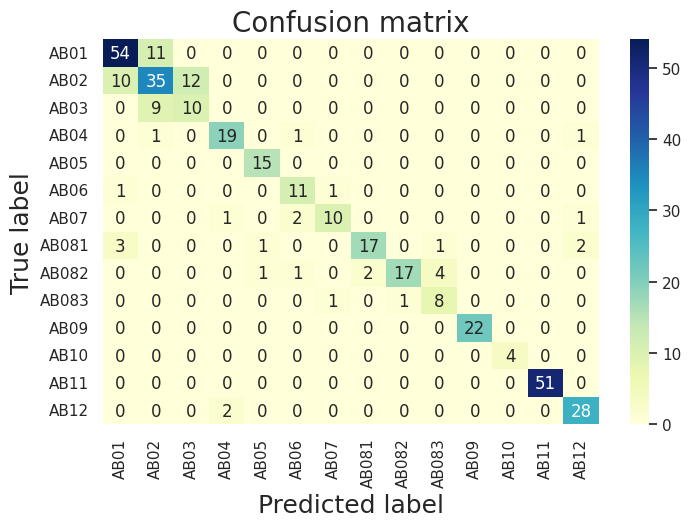

In [20]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)